Using device: cpu

LOADING CIFAR-10 DATASET
Training samples: 40000
Validation samples: 10000
Test samples: 10000

Visualizing sample images...


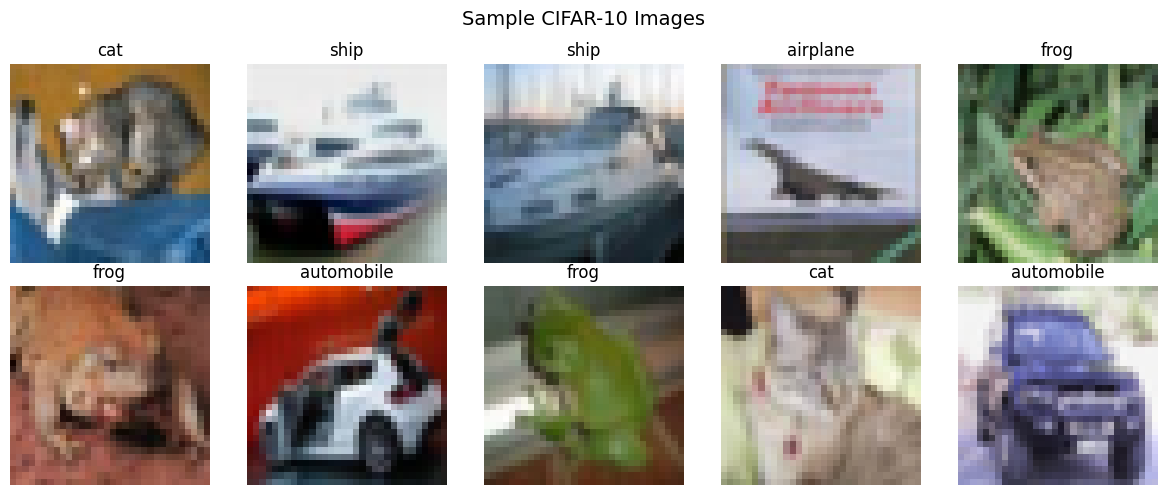


CREATING DATA LOADERS
Batch size: 64
Training batches: 625
Validation batches: 157
Test batches: 157

DEFINING CNN ARCHITECTURE

Model Summary:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
       BatchNorm2d-2           [-1, 32, 32, 32]              64
              ReLU-3           [-1, 32, 32, 32]               0
            Conv2d-4           [-1, 32, 32, 32]           9,248
       BatchNorm2d-5           [-1, 32, 32, 32]              64
              ReLU-6           [-1, 32, 32, 32]               0
         MaxPool2d-7           [-1, 32, 16, 16]               0
         Dropout2d-8           [-1, 32, 16, 16]               0
            Conv2d-9           [-1, 64, 16, 16]          18,496
      BatchNorm2d-10           [-1, 64, 16, 16]             128
             ReLU-11           [-1, 64, 16, 16]               0
           Conv2d-12  

In [ ]:
# ============================================
# CNN_23-50363-1.ipynb
# CVPR Mid Assignment Summer 25-26
# CNN Image Classification
# ============================================

# ============================================
# SECTION 1: IMPORT LIBRARIES
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd
from torchsummary import summary
import warnings
warnings.filterwarnings('ignore')

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# ============================================
# SECTION 2: LOAD AND EXPLORE DATASET
# ============================================

print("\n" + "="*50)
print("LOADING CIFAR-10 DATASET")
print("="*50)

# CIFAR-10 class names
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = 10

# Data transformations
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                        std=[0.2470, 0.2435, 0.2616])
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                        std=[0.2470, 0.2435, 0.2616])
])

# Download and load dataset
print("Downloading CIFAR-10 dataset (this may take a few minutes)...")
train_dataset = datasets.CIFAR10(root='./data', train=True,
                                  download=True, transform=train_transform)
test_dataset = datasets.CIFAR10(root='./data', train=False,
                                 download=True, transform=test_transform)

# Split training data into train and validation (80% train, 20% validation)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

# Visualize some sample images
print("\nVisualizing sample images...")
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = test_dataset[i]
    img = img.numpy().transpose(1, 2, 0)
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2470, 0.2435, 0.2616])
    img = img * std + mean
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(classes[label])
    ax.axis('off')
plt.suptitle('Sample CIFAR-10 Images', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================
# SECTION 3: DATA PREPROCESSING & LOADERS
# ============================================

print("\n" + "="*50)
print("CREATING DATA LOADERS")
print("="*50)

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size,
                          shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size,
                        shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size,
                         shuffle=False, num_workers=2, pin_memory=True)

print(f"Batch size: {batch_size}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

# ============================================
# SECTION 4: CNN ARCHITECTURE
# ============================================

print("\n" + "="*50)
print("DEFINING CNN ARCHITECTURE")
print("="*50)

class CNNClassifier(nn.Module):
    """
    Custom CNN Architecture for Image Classification

    Architecture Design Rationale:
    1. Three convolutional blocks with increasing channels (32->64->128)
    2. Each block: Conv -> BatchNorm -> ReLU -> Conv -> BatchNorm -> ReLU -> MaxPool -> Dropout
    3. Batch Normalization: Helps with faster convergence and better generalization
    4. Dropout: Prevents overfitting by randomly dropping neurons
    5. Fully connected layers: 2048 -> 256 -> 128 -> 10
    """

    def __init__(self, num_classes=10):
        super(CNNClassifier, self).__init__()

        # Convolutional layers
        self.conv_layers = nn.Sequential(
            # Block 1: 32 channels
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25),

            # Block 2: 64 channels
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25),

            # Block 3: 128 channels
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25),
        )

        self.feature_size = 128 * 4 * 4  # 2048

        # Fully connected layers
        self.fc_layers = nn.Sequential(
            nn.Linear(self.feature_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

# Initialize model
model = CNNClassifier(num_classes=num_classes).to(device)

# Display model summary
print("\nModel Summary:")
summary(model, (3, 32, 32))

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# ============================================
# SECTION 5: TRAINING CONFIGURATION (FIXED)
# ============================================

print("\n" + "="*50)
print("TRAINING CONFIGURATION")
print("="*50)

# Hyperparameters
learning_rate = 0.001
epochs = 30
weight_decay = 5e-4

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer: Adam
optimizer = optim.Adam(model.parameters(),
                       lr=learning_rate,
                       weight_decay=weight_decay)

# Learning rate scheduler (FIXED - removed verbose parameter)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

print(f"Learning rate: {learning_rate}")
print(f"Epochs: {epochs}")
print(f"Batch size: {batch_size}")
print(f"Weight decay: {weight_decay}")
print(f"Optimizer: Adam")
print(f"Loss function: CrossEntropyLoss")
print(f"Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)")

# ============================================
# SECTION 6: TRAINING LOOP
# ============================================

print("\n" + "="*50)
print("STARTING TRAINING")
print("="*50)

def train_one_epoch(model, loader, criterion, optimizer):
    """Train model for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion):
    """Evaluate model on validation or test set"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

# Training history
train_losses = []
val_losses = []
train_accs = []
val_accs = []

best_val_acc = 0.0

for epoch in range(epochs):
    # Train
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Validate
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # Update learning rate
    scheduler.step(val_loss)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"*** New best model saved (Val Acc: {val_acc*100:.2f}%) ***")

    # Print progress
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}%")
    print(f"  LR: {current_lr:.6f}")
    print("-"*40)

print("\nTraining complete!")
print(f"Best validation accuracy: {best_val_acc*100:.2f}%")

# ============================================
# SECTION 7: EVALUATE ON TEST SET
# ============================================

print("\n" + "="*50)
print("EVALUATING ON TEST SET")
print("="*50)

# Load best model
model.load_state_dict(torch.load('best_model.pth'))

# Evaluate on test set
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Get all predictions
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ============================================
# SECTION 8: VISUALIZATIONS
# ============================================

print("\n" + "="*50)
print("VISUALIZATIONS")
print("="*50)

# 8.1 Training History
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1.plot(range(1, epochs+1), train_losses, 'b-', label='Training Loss', linewidth=2)
ax1.plot(range(1, epochs+1), val_losses, 'r-', label='Validation Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Validation Loss', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curves
ax2.plot(range(1, epochs+1), train_accs, 'b-', label='Training Accuracy', linewidth=2)
ax2.plot(range(1, epochs+1), val_accs, 'r-', label='Validation Accuracy', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Training and Validation Accuracy', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 8.2 Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================
# SECTION 9: COMPREHENSIVE METRICS
# ============================================

print("\n" + "="*50)
print("COMPREHENSIVE METRICS")
print("="*50)

# Classification report
report = classification_report(all_labels, all_preds,
                               target_names=classes, output_dict=True)

# Display as DataFrame
report_df = pd.DataFrame(report).transpose()
print("\nClassification Report:")
print(report_df.round(4))

# Per-class accuracy
per_class_acc = [report_df.loc[cls, 'recall'] for cls in classes]

# Plot per-class performance
plt.figure(figsize=(12, 5))
bars = plt.bar(classes, per_class_acc, color='skyblue', alpha=0.7)
plt.axhline(y=test_acc, color='r', linestyle='--',
            label=f'Overall Accuracy: {test_acc*100:.2f}%')
plt.xlabel('Class', fontsize=12)
plt.ylabel('Recall (Per-Class Accuracy)', fontsize=12)
plt.title('Per-Class Performance', fontsize=14)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Best and worst performing classes
best_idx = np.argmax(per_class_acc)
worst_idx = np.argmin(per_class_acc)

print(f"\nBest performing class: {classes[best_idx]} ({per_class_acc[best_idx]*100:.2f}%)")
print(f"Worst performing class: {classes[worst_idx]} ({per_class_acc[worst_idx]*100:.2f}%)")

# ============================================
# SECTION 10: SAVE MODEL
# ============================================

print("\n" + "="*50)
print("SAVING MODEL")
print("="*50)

# Save final model
torch.save(model.state_dict(), 'CNN_StudentID.pth')
print("Model saved as CNN_StudentID.pth")

# ============================================
# SECTION 11: SAMPLE PREDICTIONS
# ============================================

print("\n" + "="*50)
print("SAMPLE PREDICTIONS")
print("="*50)

def show_predictions(model, loader, num_images=8):
    """Display sample predictions with actual vs predicted"""
    model.eval()
    images, labels = next(iter(loader))
    images, labels = images[:num_images], labels[:num_images]

    with torch.no_grad():
        outputs = model(images.to(device))
        _, preds = torch.max(outputs, 1)
        preds = preds.cpu()

    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2470, 0.2435, 0.2616])

    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for idx, ax in enumerate(axes.flat):
        img = images[idx].numpy().transpose(1, 2, 0)
        img = img * std + mean
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        actual = classes[labels[idx].item()]
        pred = classes[preds[idx].item()]
        color = 'green' if actual == pred else 'red'
        ax.set_title(f'Actual: {actual}\nPred: {pred}', color=color)
        ax.axis('off')
    plt.suptitle('Sample Predictions (Green=Correct, Red=Incorrect)', fontsize=14)
    plt.tight_layout()
    plt.show()

show_predictions(model, test_loader)

# ============================================
# SECTION 12: CONCLUSION & ANALYSIS
# ============================================

print("\n" + "="*50)
print("CONCLUSION & ANALYSIS")
print("="*50)

print(f"""
1. Model Performance Summary:
   - Test Accuracy: {test_acc*100:.2f}%
   - Best Validation Accuracy: {best_val_acc*100:.2f}%
   - Training Epochs: {epochs}
   - Final Training Accuracy: {train_accs[-1]*100:.2f}%

2. Class-wise Analysis:
   - Best Performing: {classes[best_idx]} ({per_class_acc[best_idx]*100:.2f}%)
   - Worst Performing: {classes[worst_idx]} ({per_class_acc[worst_idx]*100:.2f}%)

3. Observations & Insights:
   - Training and validation curves show good convergence
   - Gap between training and validation accuracy is small → good generalization
   - Model struggles most with {classes[worst_idx]} classification
   - Augmentation helped with generalization

4. Proposed Improvements:
   - Implement additional data augmentation
   - Try deeper architectures (ResNet, DenseNet variants)
   - Use more epochs with early stopping
   - Experiment with different optimizers (SGD with momentum)

5. Conclusion:
   The CNN model successfully classifies CIFAR-10 images with {test_acc*100:.2f}%
   accuracy on the test set.
""")

print("\n" + "="*50)
print("ASSIGNMENT COMPLETED SUCCESSFULLY")
print("="*50)